In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch_numopt
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.datasets import *
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, f1_score
from train_loop import train_loop

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(in_channels=3, out_channels=2, kernel_size=3, padding='same')
        self.maxpool = nn.MaxPool2d(3)
        self.fc1 = nn.Linear(200, 25)
        self.fc2 = nn.Linear(25, 2)

    def forward(self, x):
        x = torch.relu(self.conv(x))
        x = self.maxpool(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

In [4]:
# For CIFAR-10 binary classification (e.g., cats vs dogs)
transform_cifar = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

full_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_cifar)
# Filter and remap labels in one go
class RemappedSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, class_map):
        self.dataset = dataset
        self.class_map = class_map
        self.indices = [i for i, (_, label) in enumerate(dataset) if label in class_map]

    def __len__(self):
        return len(self.indices)//5
        # return 800

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        return img, self.class_map[label]

# Use it
class_map = {3: 0, 5: 1}   # cat -> 0, dog -> 1
train_dataset = RemappedSubset(full_train, class_map)
# # Filter for two classes (e.g., class 3=cat, class 5=dog)
# train_indices = [i for i, (_, label) in enumerate(full_train) if label in [3, 5]]
# train_dataset = Subset(full_train, train_indices)

# Create DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [5]:
len(train_loader.dataset)

2000

In [6]:
xshape = train_dataset.dataset[0][0].shape
model = Net().to(device)
loss_fn = nn.CrossEntropyLoss()

opt = torch_numopt.NewtonLS(
    model=model,
    solver="pinv-trunc",
    line_search_method="backtrack",
    line_search_cond="armijo",
    damping="identity",
    mu=1e-2,
)

model, loss_history = train_loop(
    model,
    loss_fn,
    opt,
    train_loader,
    epochs=100,
    max_patience=10
)

epoch:  0, loss: 0.9164400100708008
epoch:  1, loss: 0.8723515272140503
epoch:  2, loss: 40.26085662841797
epoch:  3, loss: 0.7148521542549133
epoch:  4, loss: 0.7067570090293884
epoch:  5, loss: 0.7225772142410278
epoch:  6, loss: 0.7186945676803589
epoch:  7, loss: 0.7027366161346436
epoch:  8, loss: 0.7138649225234985
epoch:  9, loss: 0.7090502977371216
epoch:  10, loss: 0.705522358417511
epoch:  11, loss: 0.7023617029190063
epoch:  12, loss: 0.7123185396194458
epoch:  13, loss: 0.7172089219093323
epoch:  14, loss: 0.7023492455482483
epoch:  15, loss: 0.7063268423080444
epoch:  16, loss: 0.7051312923431396
epoch:  17, loss: 0.7123738527297974
epoch:  18, loss: 0.7066726684570312
epoch:  19, loss: 0.7086312174797058
epoch:  20, loss: 0.7133491039276123
epoch:  21, loss: 0.7030279040336609
epoch:  22, loss: 0.7111167907714844
epoch:  23, loss: 0.7089926600456238
epoch:  24, loss: 0.7120746970176697
epoch:  25, loss: 0.7075671553611755
epoch:  26, loss: 0.7111270427703857
epoch:  27, l

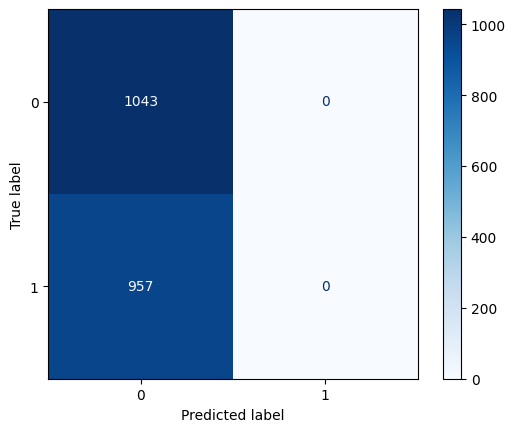

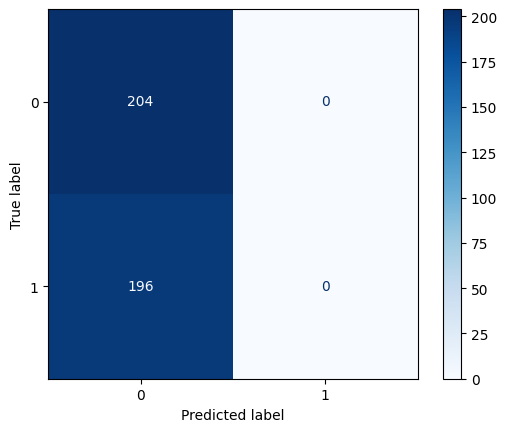

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

full_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
class_map = {3: 0, 5: 1}
test_dataset = RemappedSubset(full_test, class_map)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        y_true.append(y.cpu())
        y_pred.append(model(x).argmax(1).cpu())

ConfusionMatrixDisplay.from_predictions(torch.cat(y_true), torch.cat(y_pred), cmap="Blues")

y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        y_true.append(y.cpu())
        y_pred.append(model(x).argmax(1).cpu())

ConfusionMatrixDisplay.from_predictions(torch.cat(y_true), torch.cat(y_pred), cmap="Blues")